## Task Overview

In this lab you will build a **Convolutional Neural Network (CNN)** and use it to
classify images from the
[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset.

**After completing this task, you will know how to:**

- Load and augment a color-image dataset (CIFAR-10) in PyTorch
- Build a CNN with convolutional, batch-normalization, and pooling layers
- Train the model with a standard PyTorch training loop
- Evaluate accuracy and visualize predictions

**The big idea:** convolutional layers slide small filters over the image to
detect local patterns (edges, textures, shapes). Stacking several conv blocks
lets the network build up from simple features to more complex ones, and a final
fully-connected classifier turns those features into class scores.

## Task

Follow the instructions below to complete your coding assignment.

Run the code in the sections beginning with "Static" unchanged, unless otherwise
indicated. Fill in every cell marked `## Answer here`.

### Static code

In [ ]:
#(optional if you are running this notebook in Colab)
# @title Mount drive and run imports
from google.colab import drive
drive.mount("/content/gdrive")

In [ ]:
# @title Importing Necessary Packages

import copy
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torch.utils.data as data
from torch.utils.data import DataLoader
from torchvision.transforms import v2

In [ ]:
# @title Device, seed helper, and save path

# Use a GPU if one is available, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    """Fix all random number generators for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# Modify 'save_dir' to the path where the CIFAR-10 dataset should be downloaded.
save_dir = "./data"

### Task 1
#### **Load, augment, and prepare CIFAR-10 data (Steps 1-4)**

In this task you will:

1) Define preprocessing pipelines (with augmentation for training, without for
   evaluation).
2) Load CIFAR-10 and split the training data into train and validation sets.
3) Wrap the datasets in `DataLoader`s.
4) Visualize a sample image.

#### Step 1: Define the preprocessing pipelines

Use `v2.Compose` to build two pipelines named `train_transforms` and
`test_transforms`.

- `train_transforms` (with augmentation), in order: `v2.RandomHorizontalFlip()`,
  `v2.RandomCrop(32, padding=4)`, `v2.ToImage()`,
  `v2.ToDtype(torch.float32, scale=True)`, `v2.Normalize(mean, std)`.
- `test_transforms` (no augmentation): `v2.ToImage()`,
  `v2.ToDtype(torch.float32, scale=True)`, `v2.Normalize(mean, std)`.

Use the CIFAR-10 per-channel statistics: `mean = (0.4914, 0.4822, 0.4465)` and
`std = (0.2470, 0.2435, 0.2616)`.

In [ ]:
## Answer here

# TODO: Define `train_transforms` and `test_transforms` using v2.Compose.
#
# CIFAR-10 normalization constants (mean/std per RGB channel):
#   mean = (0.4914, 0.4822, 0.4465)
#   std  = (0.2470, 0.2435, 0.2616)
#
# train_transforms (in order): RandomHorizontalFlip, RandomCrop(32, padding=4),
#   ToImage, ToDtype(torch.float32, scale=True), Normalize(mean, std)
# test_transforms: ToImage, ToDtype(torch.float32, scale=True), Normalize(mean, std)

#### Step 2: Load the data and split into train / validation

Use `datasets.CIFAR10` to create `train_data` (train=True, `train_transforms`)
and `test_data` (train=False, `test_transforms`), with `download=True`.

Then use `data.random_split` with a 90/10 ratio to split `train_data` into
`train_data` and `validate_data`. Finally, `copy.deepcopy` the validation subset
and set its `.dataset.transform` to `test_transforms` so validation images are
**not** augmented.

In [ ]:
## Answer here

# TODO:
# 1) train_data = datasets.CIFAR10(root=save_dir, train=True,
#                                  transform=train_transforms, download=True)
# 2) test_data  = datasets.CIFAR10(root=save_dir, train=False,
#                                  transform=test_transforms, download=True)
# 3) Split train_data 90/10 with data.random_split -> train_data, validate_data
# 4) validate_data = copy.deepcopy(validate_data)
#    validate_data.dataset.transform = test_transforms

Check: After creating the three datasets you should see:

    Train samples: 45000
    Validation samples: 5000
    Test samples: 10000

In [ ]:
print("Train samples:", len(train_data))
print("Validation samples:", len(validate_data))
print("Test samples:", len(test_data))

#### Step 3: Make the DataLoaders

Use `DataLoader` to create `train_loader`, `validate_loader`, and `test_loader`
with `batch_size=50`. Shuffle **only** the `train_loader`. Call `set_seed(1)`
before creating the loaders so results are reproducible.

In [ ]:
## Answer here

# TODO: Call set_seed(1) first, then create train_loader, validate_loader, and
# test_loader with DataLoader(..., batch_size=50). Shuffle ONLY train_loader.

#### Step 4: Visualize a sample image

Grab one batch from `train_loader` with `iter`/`next`, pick `idx = 1`, and
display the image with its class name as the title. Because the images are
normalized, **un-normalize** them first (multiply by `std`, add `mean`, then
clamp to `[0, 1]`) and `permute` the tensor from `(C, H, W)` to `(H, W, C)`.

In [ ]:
## Answer here

# TODO: Grab one batch from train_loader with next(iter(...)). Pick idx = 1.
# Un-normalize the image (img * std + mean, then clamp to [0, 1]), permute it
# from (C, H, W) to (H, W, C), and show it with the class name as the title.
# CIFAR-10 classes:
# ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

Check: You should see a single CIFAR-10 image displayed with its class name as the title, for example:

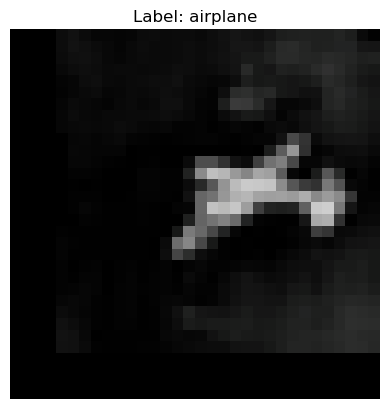

### Task 2
#### **Build the CNN model**

You will define a model class `CNN` that:

1) Passes the image through **three convolutional blocks**. Each block is
   `Conv2d -> BatchNorm2d -> ReLU -> MaxPool2d(2)`, which halves the height and
   width while increasing the number of channels (3 -> 32 -> 64 -> 128).
2) After the conv blocks the feature maps are `(batch, 128, 4, 4)`. **Flatten**
   them into a vector of length `128 * 4 * 4 = 2048`.
3) Passes that vector through a small fully-connected classifier
   (`Linear -> ReLU -> Dropout -> Linear`) to produce 10 class scores.

Fill in the model definition below.

In [ ]:
## Answer here

# TODO: Complete the CNN model.
#
# In __init__ define:
#   self.features   -> nn.Sequential(
#       Conv2d(3, 32, kernel_size=3, padding=1), BatchNorm2d(32), ReLU, MaxPool2d(2),
#       Conv2d(32, 64, kernel_size=3, padding=1), BatchNorm2d(64), ReLU, MaxPool2d(2),
#       Conv2d(64, 128, kernel_size=3, padding=1), BatchNorm2d(128), ReLU, MaxPool2d(2))
#   self.classifier -> nn.Sequential(
#       Flatten(), Linear(128*4*4, 256), ReLU(), Dropout(0.5), Linear(256, num_classes))
#
# In forward(x):
#   1) x = self.features(x)     # (B, 128, 4, 4)
#   2) return self.classifier(x)

class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: define self.features and self.classifier
        pass

    def forward(self, x):
        # TODO: implement the forward pass
        pass

Check: Instantiate the model and run one batch through it. The output shape
should be `torch.Size([50, 10])` (a batch of 50, one score per class).

In [ ]:
model = CNN().to(device)
print(model)

# Quick shape test: run one batch through the untrained model.
images, labels = next(iter(train_loader))
out = model(images.to(device))
print("Output shape:", out.shape)   # expect torch.Size([50, 10])

### Task 3
#### **Train the model**

Set up a loss function and optimizer, then train for a few epochs. After each
epoch, evaluate accuracy on the validation set and print the progress.

(Training for 10 epochs on CPU takes several minutes; a GPU is much faster.)

In [ ]:
## Answer here

# TODO:
# 1) criterion = nn.CrossEntropyLoss()
# 2) optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# 3) Loop over num_epochs = 10. Each epoch:
#      - model.train(); for images, labels in train_loader:
#            move to device, optimizer.zero_grad(), forward, loss,
#            loss.backward(), optimizer.step(), accumulate loss.
#      - model.eval(); with torch.no_grad(): loop over validate_loader and
#            count correct predictions (outputs.argmax(dim=1) == labels).
#      - print train loss and validation accuracy.

Check: Training runs for 10 epochs. The loss should fall and the validation accuracy should climb over the epochs — for example:

    Epoch 1/10 | train loss: 1.6325 | val acc: 55.68%
    Epoch 2/10 | train loss: 1.3221 | val acc: 61.40%
    Epoch 3/10 | train loss: 1.1788 | val acc: 67.14%
    Epoch 4/10 | train loss: 1.0953 | val acc: 68.74%
    Epoch 5/10 | train loss: 1.0304 | val acc: 69.22%
    Epoch 6/10 | train loss: 0.9781 | val acc: 72.20%
    Epoch 7/10 | train loss: 0.9371 | val acc: 73.76%
    Epoch 8/10 | train loss: 0.8996 | val acc: 74.34%
    Epoch 9/10 | train loss: 0.8712 | val acc: 75.52%
    Epoch 10/10 | train loss: 0.8421 | val acc: 74.98%

(Your exact numbers will vary from run to run.)

### Task 4
#### **Evaluate on the test set and visualize predictions**

#### Step 1: Compute test accuracy

Loop over `test_loader` (inside `torch.no_grad()`), count correct predictions,
and print the overall test accuracy.

In [ ]:
## Answer here

# TODO: Set model.eval(), loop over test_loader inside torch.no_grad(),
# count correct predictions, and print the test accuracy.

Check: The final test accuracy should land in a similar range:

    Test accuracy: 75.64%

(Expect roughly 75-85% depending on training randomness.)

#### Step 2: Visualize predictions

Show the first 6 test images with their predicted and true class names. Remember
to un-normalize the images before displaying.

In [ ]:
## Answer here

# TODO: Get one batch from test_loader, predict with the model
# (model(images).argmax(dim=1)), then plot the first 6 images with titles
# showing predicted vs. true class names. Un-normalize before plotting.

Check: You should see 6 test images labeled with the predicted (P) and true (T) class names — most of them matching:

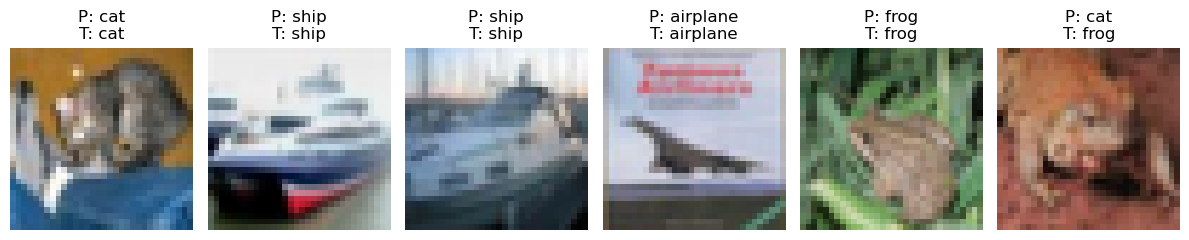